In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda

img = plt.imread("photo.jpg")
h, w, _ = img.shape
print(img.shape)


(800, 1200, 3)


In [3]:
@cuda.jit
def grayscale2d(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        dst[y, x] = np.uint8((src[y, x, 0] + src[y, x, 1] + src[y, x, 2]) / 3)


@cuda.jit
def binarize(src, dst, threshold):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        if src[y, x] >= threshold:
            dst[y, x] = 255
        else:
            dst[y, x] = 0


@cuda.jit
def brightness(src, dst, delta):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        for c in range(3):
            v = src[y, x, c] + delta
            if v > 255:
                v = 255
            if v < 0:
                v = 0
            dst[y, x, c] = v


@cuda.jit
def blend(src1, src2, dst, coef):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src1.shape[0] and x < src1.shape[1]:
        for c in range(3):
            dst[y, x, c] = np.uint8(coef * src1[y, x, c] + (1 - coef) * src2[y, x, c])


In [4]:
img2 = np.ascontiguousarray(img[:, ::-1])

devImg = cuda.to_device(img)
devImg2 = cuda.to_device(img2)
devGray = cuda.device_array((h, w), np.uint8)
devBin = cuda.device_array((h, w), np.uint8)
devBright = cuda.device_array((h, w, 3), np.uint8)
devDark = cuda.device_array((h, w, 3), np.uint8)
devBlend = cuda.device_array((h, w, 3), np.uint8)


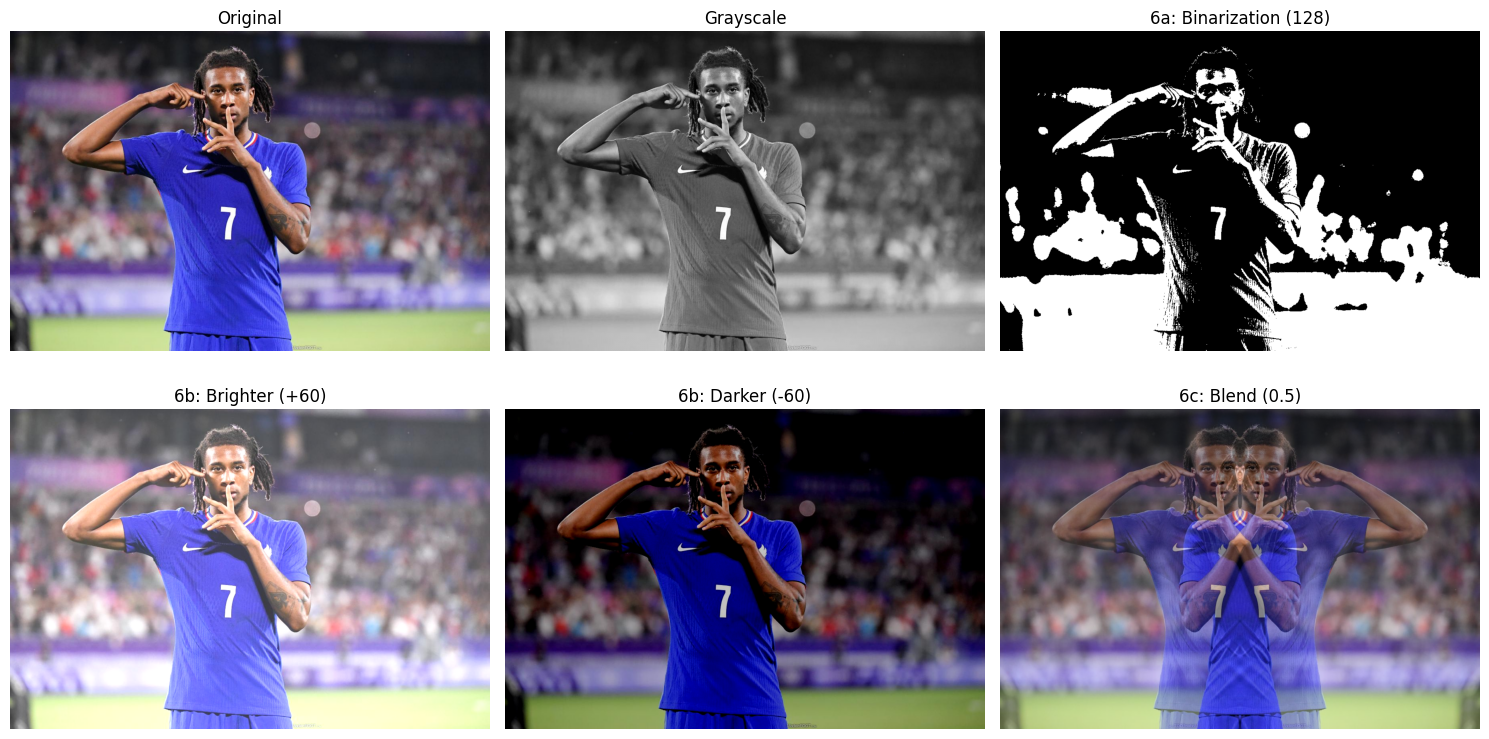

In [5]:
block = (16, 16)
grid = ((w + 15) // 16, (h + 15) // 16)

threshold = 128
grayscale2d[grid, block](devImg, devGray)
binarize[grid, block](devGray, devBin, threshold)
brightness[grid, block](devImg, devBright, 60)
brightness[grid, block](devImg, devDark, -60)
blend[grid, block](devImg, devImg2, devBlend, 0.5)
cuda.synchronize()

results = [img, devGray.copy_to_host(), devBin.copy_to_host(),
           devBright.copy_to_host(), devDark.copy_to_host(), devBlend.copy_to_host()]
titles = ["Original", "Grayscale", "6a: Binarization (128)",
          "6b: Brighter (+60)", "6b: Darker (-60)", "6c: Blend (0.5)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for k in range(6):
    ax = axes[k // 3, k % 3]
    ax.imshow(results[k], cmap="gray")
    ax.set_title(titles[k])
    ax.axis("off")
plt.tight_layout()
plt.savefig("results.png")
plt.show()


In [6]:
def measure(kernel, grid, block, *args):
    kernel[grid, block](*args)
    cuda.synchronize()
    start = time.time()
    for r in range(100):
        kernel[grid, block](*args)
    cuda.synchronize()
    return (time.time() - start) / 100


8 x 8 | binarize: 6.412267684936523e-05 | brightness: 9.409904479980469e-05 | blend: 0.0003829455375671387
16 x 8 | binarize: 3.6373138427734376e-05 | brightness: 6.430864334106446e-05 | blend: 0.00038248777389526367
16 x 16 | binarize: 3.345727920532227e-05 | brightness: 6.860733032226562e-05 | blend: 0.0003812599182128906
32 x 16 | binarize: 4.1556358337402346e-05 | brightness: 6.560087203979492e-05 | blend: 0.00038999557495117187
32 x 32 | binarize: 4.2576789855957034e-05 | brightness: 8.064031600952149e-05 | blend: 0.0003953719139099121


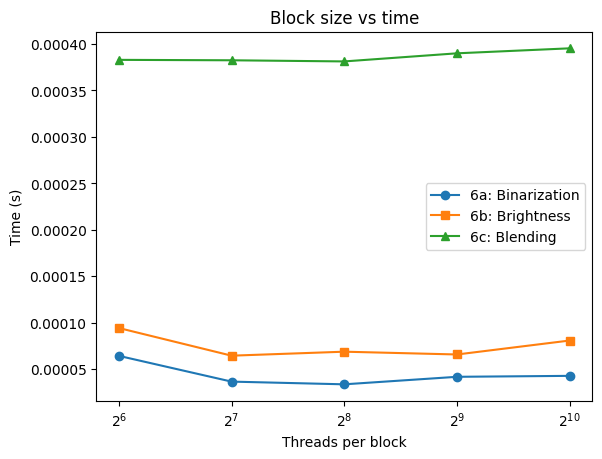

In [7]:
blocks2D = [(8, 8), (16, 8), (16, 16), (32, 16), (32, 32)]
threads = []
tBin = []
tBright = []
tBlend = []

for bx, by in blocks2D:
    grid = ((w + bx - 1) // bx, (h + by - 1) // by)
    block = (bx, by)
    t1 = measure(binarize, grid, block, devGray, devBin, threshold)
    t2 = measure(brightness, grid, block, devImg, devBright, 60)
    t3 = measure(blend, grid, block, devImg, devImg2, devBlend, 0.5)

    threads.append(bx * by)
    tBin.append(t1)
    tBright.append(t2)
    tBlend.append(t3)
    print(bx, "x", by, "| binarize:", t1, "| brightness:", t2, "| blend:", t3)

plt.plot(threads, tBin, marker="o", label="6a: Binarization")
plt.plot(threads, tBright, marker="s", label="6b: Brightness")
plt.plot(threads, tBlend, marker="^", label="6c: Blending")
plt.xscale("log", base=2)
plt.xlabel("Threads per block")
plt.ylabel("Time (s)")
plt.title("Block size vs time")
plt.legend()
plt.savefig("blocksize_vs_time.png")
plt.show()


In [8]:
@cuda.jit
def blend32(src1, src2, dst, coef):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src1.shape[0] and x < src1.shape[1]:
        for c in range(3):
            dst[y, x, c] = np.uint8(coef * np.float32(src1[y, x, c]) + (np.float32(1) - coef) * np.float32(src2[y, x, c]))

grid = ((w + 15) // 16, (h + 15) // 16)
print("blend float64:", measure(blend, grid, (16, 16), devImg, devImg2, devBlend, 0.5))
print("blend float32:", measure(blend32, grid, (16, 16), devImg, devImg2, devBlend, np.float32(0.5)))


blend float64: 0.0003823065757751465
blend float32: 8.522510528564453e-05
